In [1]:
!pip install -q torch torchvision transformers pillow matplotlib pandas

In [15]:
import os
import shutil
import torch
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration


In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [17]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model.to(device)

print("Model loaded successfully")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model loaded successfully


In [18]:
os.makedirs("images", exist_ok=True)

from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
  shutil.move(filename, f"images/{filename}")

print(sorted(os.listdir("images")))

Saving apple_picking.jpg to apple_picking.jpg
Saving bird.jpg to bird.jpg
Saving burger.jpg to burger.jpg
Saving cooking.jpg to cooking.jpg
Saving dog.jpg to dog.jpg
Saving eagle.jpg to eagle.jpg
Saving laptop.jpg to laptop.jpg
Saving meal.jpg to meal.jpg
Saving moon.jpg to moon.jpg
Saving ocean.jpg to ocean.jpg
Saving pancakes.jpg to pancakes.jpg
Saving polar_bear.jpg to polar_bear.jpg
Saving slide.jpg to slide.jpg
Saving train_station.jpg to train_station.jpg
Saving volcano.jpg to volcano.jpg
['apple_picking.jpg', 'bird.jpg', 'burger.jpg', 'cooking.jpg', 'dog.jpg', 'eagle.jpg', 'laptop.jpg', 'meal.jpg', 'moon.jpg', 'ocean.jpg', 'pancakes.jpg', 'polar_bear.jpg', 'slide.jpg', 'train_station.jpg', 'volcano.jpg']


In [19]:
def generate_caption(image):
  inputs = processor(images=image, return_tensors="pt").to(device)

  with torch.no_grad():
    output = model.generate(
        **inputs,
        num_beams=5,
        max_new_tokens=30
        )

  caption = processor.decode(output[0], skip_special_tokens=True)
  return caption

In [20]:
results = []

for filename in sorted(os.listdir("images")):
  path = f"images/{filename}"
  image = Image.open(path).convert("RGB")
  caption = generate_caption(image)

  print(f"{filename} -> {caption}")

  results.append({
      "image": filename,
      "caption": caption
  })

apple_picking.jpg -> a woman and two children in a wagon picking apples from a tree
bird.jpg -> a red bird is perched on a branch
burger.jpg -> a wooden plate with a hamburger and french fries on it
cooking.jpg -> a woman wearing a brown jacket
dog.jpg -> a brown dog carrying a stick in the woods
eagle.jpg -> an eagle flying through the air with its wings spread
laptop.jpg -> a laptop on a wooden table with a cup of coffee
meal.jpg -> a white plate topped with meat and vegetables
moon.jpg -> a full moon is seen in the dark sky
ocean.jpg -> the sky is orange
pancakes.jpg -> a stack of pancakes with blueberries on a plate
polar_bear.jpg -> a polar bear standing on its hind in the snow
slide.jpg -> a little girl sitting on a yellow slide
train_station.jpg -> a man wearing a black coat
volcano.jpg -> a volcano in the clouds with smoke coming out of it


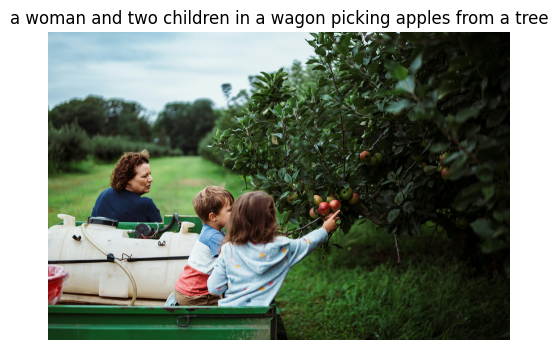

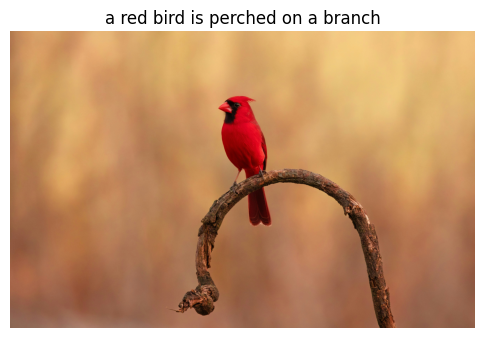

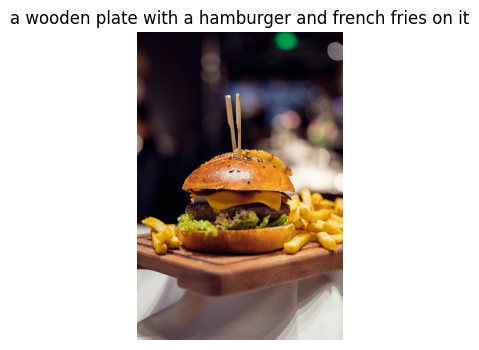

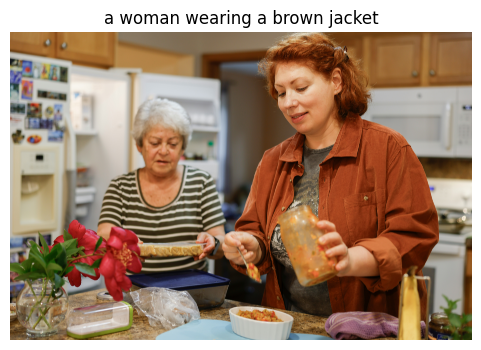

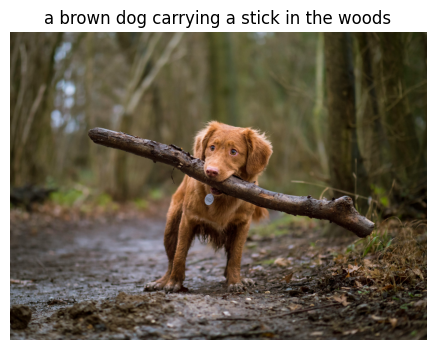

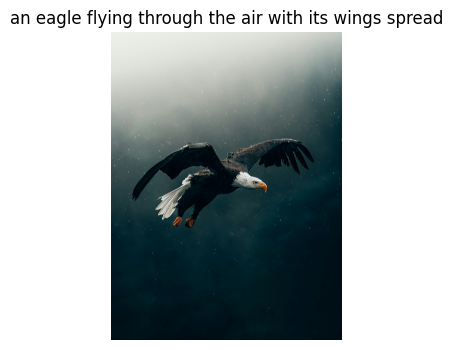

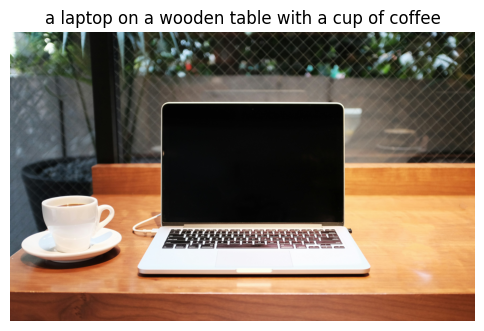

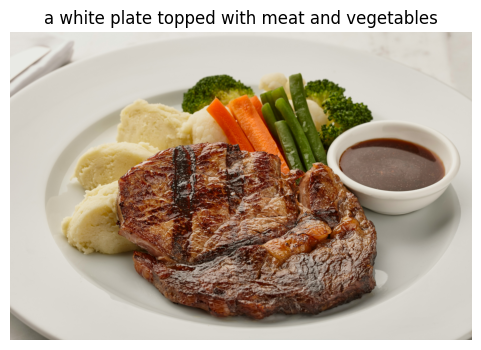

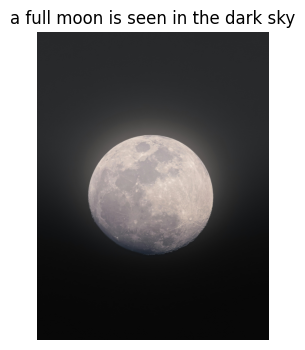

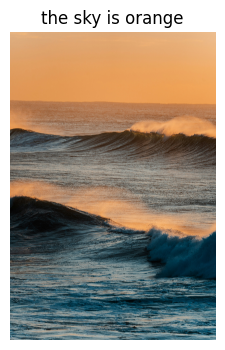

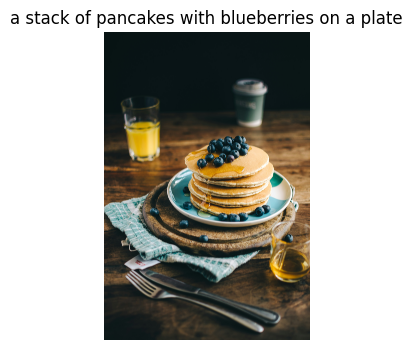

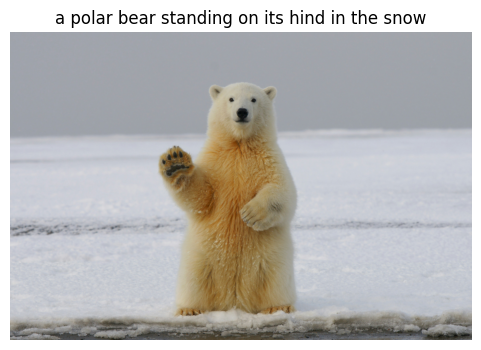

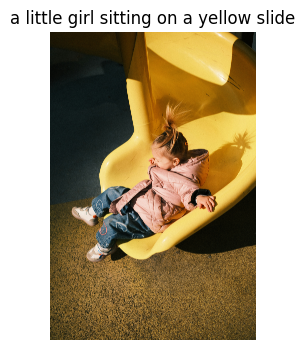

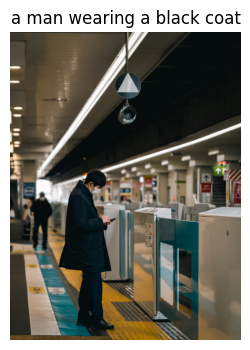

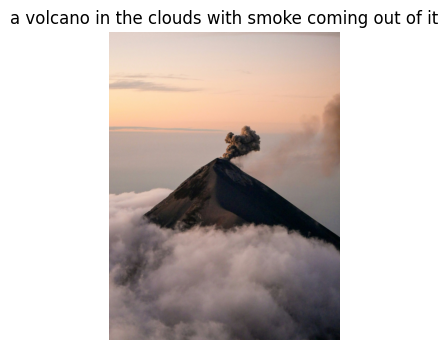

In [21]:
for item in results:
  image = Image.open(f"images/{item['image']}").convert("RGB")

  plt.figure(figsize=(6,4))
  plt.imshow(image)
  plt.title(item["caption"], wrap=True)
  plt.axis("off")
  plt.show()

In [23]:
df = pd.DataFrame(results)

df["accuracy"] = ""
df["detail"] = ""
df["clarity"] = ""
df["notes"] = ""

df.to_csv("results.csv", index=False)

print("Saved results.csv")
df

Saved results.csv


,image,caption,accuracy,detail,clarity,notes
0,apple_picking.jpg,a woman and two children in a wagon picking ap...,,,,
1,bird.jpg,a red bird is perched on a branch,,,,
2,burger.jpg,a wooden plate with a hamburger and french fri...,,,,
3,cooking.jpg,a woman wearing a brown jacket,,,,
4,dog.jpg,a brown dog carrying a stick in the woods,,,,
5,eagle.jpg,an eagle flying through the air with its wings...,,,,
6,laptop.jpg,a laptop on a wooden table with a cup of coffee,,,,
7,meal.jpg,a white plate topped with meat and vegetables,,,,
8,moon.jpg,a full moon is seen in the dark sky,,,,
9,ocean.jpg,the sky is orange,,,,


In [24]:
files.download("results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Scoring Guide**

### **Accuracy**

*   5 = caption matches image very well
*   4 = mostly correct
*   3 = somewhat correct but incomplete
*   2 = weak match
*   1 = incorrect

### **Detail**
*   5 = very descriptive
*   4 = good detail
*   3 = somewhat generic
*   2 = very vague
*   1 = almost no useful detail

### **Clarity**
*   5 = very clear and natural
*   4 = clear
*   3 = understandable but plain
*   2 = awkward
*   1 = unclear

In [29]:
uploaded_eval = files.upload()

df_eval = pd.read_csv("detailed_results.csv")

for col in ["accuracy", "detail", "clarity"]:
  df_eval[col] = pd.to_numeric(df_eval[col], errors="coerce")

print("Average Accuracy:", round(df_eval["accuracy"].mean(), 2))
print("Average Detail:", round(df_eval["detail"].mean(), 2))
print("Average Clarity:", round(df_eval["clarity"].mean(), 2))

Saving detailed_results.csv to detailed_results (1).csv
Average Accuracy: 4.53
Average Detail: 4.07
Average Clarity: 4.73


In [30]:
df_eval

,image,caption,accuracy,detail,clarity,notes
0,apple_picking.jpg,a woman and two children in a wagon picking ap...,5,5,5,Strong caption with clear subject
1,bird.jpg,a red bird is perched on a branch,5,4,5,It could've added the type of bird
2,burger.jpg,a wooden plate with a hamburger and french fri...,5,5,5,"Straight to the point, accurate"
3,cooking.jpg,a woman wearing a brown jacket,3,2,4,"Left out a lot of details, but was still corre..."
4,dog.jpg,a brown dog carrying a stick in the woods,5,5,5,"Strong caption, detailed, very accurate"
5,eagle.jpg,an eagle flying through the air with its wings...,5,5,5,"Strong caption, detailed, very accurate"
6,laptop.jpg,a laptop on a wooden table with a cup of coffee,5,4,5,"Simple and straight forward, could've had a li..."
7,meal.jpg,a white plate topped with meat and vegetables,5,4,5,Could've specified the kind of meat or vegetables
8,moon.jpg,a full moon is seen in the dark sky,5,5,5,"Simple, accurate, straight forward"
9,ocean.jpg,the sky is orange,2,2,3,"Missed the main subject of the picture, vague"


## Qualitative Analysis



In [31]:
best_examples = df_eval.sort_values(by=["accuracy", "detail", "clarity"], ascending=False).head(3)
weak_examples = df_eval.sort_values(by=["accuracy", "detail", "clarity"], ascending=True).head(3)

print("Best Examples")
display(best_examples)

print("\nWeak Examples")
display(weak_examples)

Best Examples


,image,caption,accuracy,detail,clarity,notes
0,apple_picking.jpg,a woman and two children in a wagon picking ap...,5,5,5,Strong caption with clear subject
2,burger.jpg,a wooden plate with a hamburger and french fri...,5,5,5,"Straight to the point, accurate"
4,dog.jpg,a brown dog carrying a stick in the woods,5,5,5,"Strong caption, detailed, very accurate"



Weak Examples


,image,caption,accuracy,detail,clarity,notes
9,ocean.jpg,the sky is orange,2,2,3,"Missed the main subject of the picture, vague"
3,cooking.jpg,a woman wearing a brown jacket,3,2,4,"Left out a lot of details, but was still corre..."
13,train_station.jpg,a man wearing a black coat,3,3,5,Left out the entire background
